In [ ]:
# ====================================================================
# 1. SETUP ENVIRONMENT
# ====================================================================

from google.colab import drive
drive.mount('/content/drive')

print("📦 Sedang menyalin dan mengekstrak dataset ke lokal Colab...")

!cp "/content/drive/MyDrive/DATASET_UJICOBA.zip" "/content/"
!unzip -q "/content/DATASET_UJICOBA.zip" -d "/content/dataset_lokal"

print("✅ Dataset berhasil dipindahkan ke lokal Colab!\n")

import os
import cv2
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ====================================================================
# Menentukan path dataset
# ====================================================================

base_path = '/content/dataset_lokal/DATASET_UJICOBA'

train_gingivitis_dir = os.path.join(base_path, 'Gingivitis')
train_non_gingivitis_dir = os.path.join(base_path, 'Non_Gingivitis')

print("📍 Jalur dataset:")
print(f"Gingivitis      : {train_gingivitis_dir}")
print(f"Non_Gingivitis  : {train_non_gingivitis_dir}")

print("\n🔍 Verifikasi:")
print("Gingivitis ada?      :", os.path.exists(train_gingivitis_dir))
print("Non_Gingivitis ada?  :", os.path.exists(train_non_gingivitis_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Sedang menyalin dan mengekstrak dataset ke lokal Colab...
replace /content/dataset_lokal/DATASET_UJICOBA/Non_Gingivitis/ulcer (55).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Dataset berhasil dipindahkan ke lokal Colab!

📍 Jalur dataset:
Gingivitis      : /content/dataset_lokal/DATASET_UJICOBA/Gingivitis
Non_Gingivitis  : /content/dataset_lokal/DATASET_UJICOBA/Non_Gingivitis

🔍 Verifikasi:
Gingivitis ada?      : True
Non_Gingivitis ada?  : True


--- Jumlah Data Awal ---
Jumlah citra Gingivitis     : 600
Jumlah citra Non-Gingivitis : 600
Total Keseluruhan           : 1200

Menampilkan Sampel Acak:


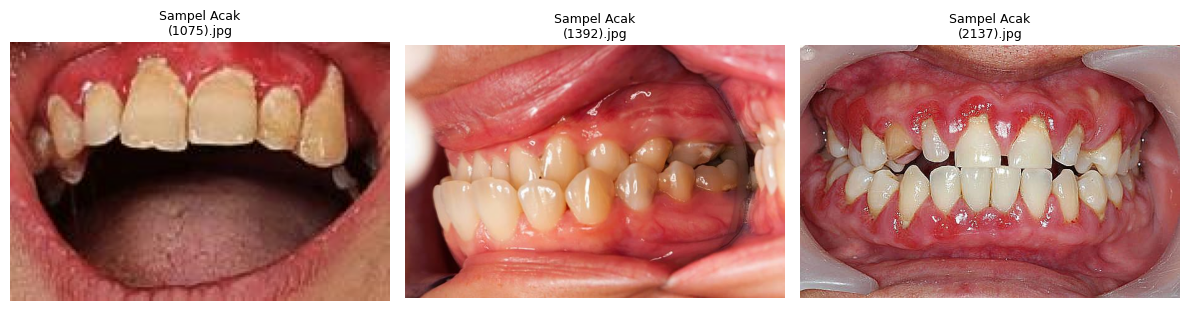

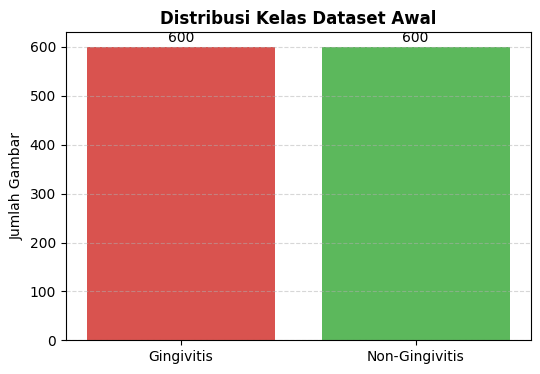

In [ ]:
# ==========================================
# 2. DATA UNDERSTANDING
# ==========================================

# A. Menghitung Jumlah File
def count_files(directory):
    return len([
        f for f in os.listdir(directory)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

total_gingivitis = count_files(train_gingivitis_dir)
total_non = count_files(train_non_gingivitis_dir)

print("--- Jumlah Data Awal ---")
print(f"Jumlah citra Gingivitis     : {total_gingivitis}")
print(f"Jumlah citra Non-Gingivitis : {total_non}")
print(f"Total Keseluruhan           : {total_gingivitis + total_non}\n")


# B. Visualisasi Sampel Secara Acak
def intip_dataset_random(jumlah_sampel=3):

    semua_file = [
        f for f in os.listdir(train_gingivitis_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    jumlah_sampel = min(jumlah_sampel, len(semua_file))
    sampel_pilihan = random.sample(semua_file, jumlah_sampel)

    plt.figure(figsize=(12, 4))

    for i, nama_file in enumerate(sampel_pilihan):

        path_foto = os.path.join(train_gingivitis_dir, nama_file)

        img = cv2.imread(path_foto)

        if img is None:
            print(f"Gagal membaca: {nama_file}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, jumlah_sampel, i+1)
        plt.imshow(img)
        plt.title(f"Sampel Acak\n{nama_file}", fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("Menampilkan Sampel Acak:")
intip_dataset_random()


# C. Cek Distribusi Kelas
plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['Gingivitis', 'Non-Gingivitis'],
    [total_gingivitis, total_non],
    color=['#d9534f', '#5cb85c']
)

plt.title('Distribusi Kelas Dataset Awal', fontweight='bold')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 5,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
# ==========================================================
# 3. DATA PREPARATION
# HOLD-OUT TEST SET (15%) + 5-FOLD STRATIFIED CROSS VALIDATION
# ==========================================================

import os
import random
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

# ==========================================================
# A. REPRODUCIBILITY
# ==========================================================

random.seed(42)
np.random.seed(42)

# ==========================================================
# B. KUMPULKAN PATH DAN LABEL
# ==========================================================

all_paths = []
all_labels = []

# ----------------------------------------------------------
# Kelas Gingivitis = 0
# ----------------------------------------------------------

for img_name in sorted(os.listdir(train_gingivitis_dir)):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_paths.append(
            os.path.join(train_gingivitis_dir, img_name)
        )
        all_labels.append(0)

# ----------------------------------------------------------
# Kelas Non-Gingivitis = 1
# ----------------------------------------------------------

for img_name in sorted(os.listdir(train_non_gingivitis_dir)):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_paths.append(
            os.path.join(train_non_gingivitis_dir, img_name)
        )
        all_labels.append(1)

# Konversi ke NumPy Array
all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# ==========================================================
# C. INFORMASI DATASET
# ==========================================================

print("=" * 60)
print("TOTAL DATASET")
print("=" * 60)

print(f"Total data              : {len(all_paths)} gambar")
print(f"Gingivitis              : {np.sum(all_labels == 0)} gambar")
print(f"Non-Gingivitis          : {np.sum(all_labels == 1)} gambar")

# ==========================================================
# D. HOLD-OUT TEST SET (15%)
#
# 15% data disimpan sebagai TEST SET FINAL.
# Test set tidak digunakan dalam proses K-Fold.
# ==========================================================

X_cv_paths, X_test_paths, y_cv, y_test = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

print("\n" + "=" * 60)
print("HOLD-OUT TEST SET")
print("=" * 60)

print(f"Data untuk 5-Fold CV   : {len(X_cv_paths)} gambar (85%)")
print(f"Data Test Final        : {len(X_test_paths)} gambar (15%)")

print("\nDistribusi Data Test:")
print(f"  Gingivitis            : {np.sum(y_test == 0)} gambar")
print(f"  Non-Gingivitis        : {np.sum(y_test == 1)} gambar")

# ==========================================================
# E. STRATIFIED 5-FOLD CROSS VALIDATION
#
# 85% data (1.020 gambar) dibagi menjadi 5 fold.
#
# Setiap fold:
#   Training    = 80% dari data CV = 816 gambar
#   Validation  = 20% dari data CV = 204 gambar
#
# Karena data CV adalah 85% dari total:
#   Training    = 68% dari total dataset
#   Validation  = 17% dari total dataset
#   Test        = 15% dari total dataset
# ==========================================================

k_folds = 5

skf = StratifiedKFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

folds_data = []

print("\n" + "=" * 60)
print("5-FOLD STRATIFIED CROSS VALIDATION")
print("=" * 60)

for fold_no, (train_index, val_index) in enumerate(
    skf.split(X_cv_paths, y_cv),
    start=1
):

    # ------------------------------------------------------
    # Data Training
    # ------------------------------------------------------

    X_train_fold = X_cv_paths[train_index]
    y_train_fold = y_cv[train_index]

    # ------------------------------------------------------
    # Data Validation
    # ------------------------------------------------------

    X_val_fold = X_cv_paths[val_index]
    y_val_fold = y_cv[val_index]

    # ------------------------------------------------------
    # Simpan data fold
    # ------------------------------------------------------

    folds_data.append({
        "fold": fold_no,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

    # ------------------------------------------------------
    # Distribusi kelas
    # ------------------------------------------------------

    train_g = np.sum(y_train_fold == 0)
    train_ng = np.sum(y_train_fold == 1)

    val_g = np.sum(y_val_fold == 0)
    val_ng = np.sum(y_val_fold == 1)

    print(f"\nFold {fold_no}")
    print("-" * 40)

    print(
        f"Train      : {len(X_train_fold)} gambar "
        f"(Gingivitis: {train_g}, "
        f"Non-Gingivitis: {train_ng})"
    )

    print(
        f"Validation : {len(X_val_fold)} gambar "
        f"(Gingivitis: {val_g}, "
        f"Non-Gingivitis: {val_ng})"
    )

# ==========================================================
# F. VALIDASI HASIL PEMBAGIAN
# ==========================================================

print("\n" + "=" * 60)
print("RINGKASAN PEMBAGIAN DATA")
print("=" * 60)

print(f"Total Dataset       : {len(all_paths)} gambar")
print(f"Test Set            : {len(X_test_paths)} gambar")
print(f"Data K-Fold         : {len(X_cv_paths)} gambar")
print(f"Jumlah Fold         : {k_folds}")
print(f"Train per Fold      : {len(folds_data[0]['X_train'])} gambar")
print(f"Validation per Fold : {len(folds_data[0]['X_val'])} gambar")

print("\nPersentase terhadap total dataset:")
print(f"Test                 : {len(X_test_paths)/len(all_paths)*100:.2f}%")
print(
    f"Train per Fold       : "
    f"{len(folds_data[0]['X_train'])/len(all_paths)*100:.2f}%"
)
print(
    f"Validation per Fold  : "
    f"{len(folds_data[0]['X_val'])/len(all_paths)*100:.2f}%"
)

print("\n" + "=" * 60)
print("✅ DATA PREPARATION SELESAI")
print("✅ 15% TEST SET TERKUNCI")
print("✅ 85% DATA CV TERBAGI MENJADI 5 FOLD")
print("✅ STRATIFIED CROSS VALIDATION AKTIF")
print("=" * 60)

TOTAL DATASET
Total data              : 1200 gambar
Gingivitis              : 600 gambar
Non-Gingivitis          : 600 gambar

HOLD-OUT TEST SET
Data untuk 5-Fold CV   : 1020 gambar (85%)
Data Test Final        : 180 gambar (15%)

Distribusi Data Test:
  Gingivitis            : 90 gambar
  Non-Gingivitis        : 90 gambar

5-FOLD STRATIFIED CROSS VALIDATION

Fold 1
----------------------------------------
Train      : 816 gambar (Gingivitis: 408, Non-Gingivitis: 408)
Validation : 204 gambar (Gingivitis: 102, Non-Gingivitis: 102)

Fold 2
----------------------------------------
Train      : 816 gambar (Gingivitis: 408, Non-Gingivitis: 408)
Validation : 204 gambar (Gingivitis: 102, Non-Gingivitis: 102)

Fold 3
----------------------------------------
Train      : 816 gambar (Gingivitis: 408, Non-Gingivitis: 408)
Validation : 204 gambar (Gingivitis: 102, Non-Gingivitis: 102)

Fold 4
----------------------------------------
Train      : 816 gambar (Gingivitis: 408, Non-Gingivitis: 408)
Va

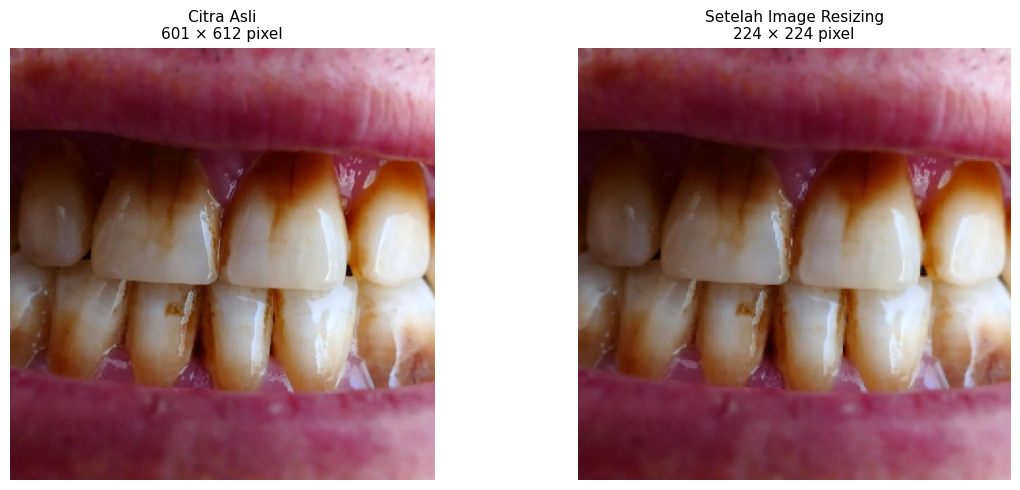

HASIL IMAGE RESIZING
Nama file       : calculus (39).jpg
Ukuran asli     : 601 × 612 pixel
Ukuran setelah  : 224 × 224 pixel
✅ Image resizing berhasil


In [ ]:
# ==========================================================
# 4. PREPROCESSING - IMAGE RESIZING
# ==========================================================

import random
import cv2
import matplotlib.pyplot as plt
import os

# ==========================================================
# A. PILIH SATU CITRA SECARA ACAK
# ==========================================================

sample_path = random.choice(X_cv_paths)

nama_file = os.path.basename(sample_path)

# Baca citra
img_bgr = cv2.imread(sample_path)

if img_bgr is None:
    raise ValueError(f"Gagal membaca gambar: {sample_path}")

# Konversi BGR → RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ==========================================================
# B. RESIZE CITRA MENJADI 224 × 224
# ==========================================================

height_original, width_original = img_rgb.shape[:2]

img_resize = cv2.resize(
    img_rgb,
    (224, 224)
)

# ==========================================================
# C. VISUALISASI
# ==========================================================

plt.figure(figsize=(12, 5))

# Citra asli
plt.subplot(1, 2, 1)

plt.imshow(img_rgb)

plt.title(
    f"Citra Asli\n"
    f"{width_original} × {height_original} pixel",
    fontsize=11
)

plt.axis("off")


# Citra setelah resize
plt.subplot(1, 2, 2)

plt.imshow(img_resize)

plt.title(
    "Setelah Image Resizing\n"
    "224 × 224 pixel",
    fontsize=11
)

plt.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("HASIL IMAGE RESIZING")
print("=" * 60)
print(f"Nama file       : {nama_file}")
print(f"Ukuran asli     : {width_original} × {height_original} pixel")
print("Ukuran setelah  : 224 × 224 pixel")
print("✅ Image resizing berhasil")

PREPROCESSING FUNCTION
Urutan preprocessing:
1. Load & Decode
2. Resize → 224 × 224
3. Image Sharpening → hanya skenario Sharp
4. Normalisasi → 0–1

✅ Fungsi preprocessing berhasil dibuat.


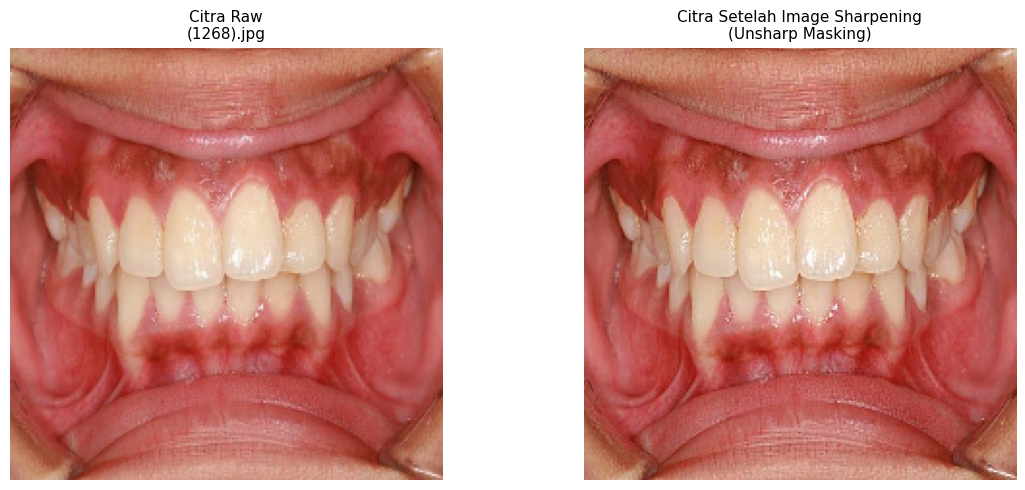

In [ ]:
# ==========================================================
# 5. PREPROCESSING FUNCTION
# LOAD → RESIZE → SHARPENING (OPTIONAL) → NORMALISASI
# ==========================================================

import tensorflow as tf
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# ==========================================================
# A. FUNGSI LOAD DAN PREPROCESSING
# ==========================================================

def load_and_preprocess(path, label, apply_sharpening=False):

    # ------------------------------------------------------
    # 1. Membaca citra
    # ------------------------------------------------------

    image = tf.io.read_file(path)

    # Decode citra menjadi RGB
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    # ------------------------------------------------------
    # 2. Image Resizing
    # ------------------------------------------------------

    image = tf.image.resize(
        image,
        [224, 224]
    )

    # ------------------------------------------------------
    # 3. Image Sharpening (Opsional)
    #
    # Jika apply_sharpening=False:
    #   citra langsung menuju normalisasi
    #
    # Jika apply_sharpening=True:
    #   dilakukan Unsharp Masking
    # ------------------------------------------------------

    def opencv_preprocessing(img_tensor):

        # Tensor → NumPy
        img_numpy = img_tensor.numpy().astype(np.uint8)

        if apply_sharpening:

            # Gaussian Blur
            blurred = cv2.GaussianBlur(
                img_numpy,
                (5, 5),
                1.0
            )

            # Unsharp Masking
            img_numpy = cv2.addWeighted(
                img_numpy,
                1.5,       # alpha
                blurred,
                -0.5,      # beta
                0          # gamma
            )

            # Menjaga nilai pixel tetap 0–255
            img_numpy = np.clip(
                img_numpy,
                0,
                255
            ).astype(np.uint8)

        # --------------------------------------------------
        # 4. Normalisasi Pixel
        # 0–255 → 0–1
        # --------------------------------------------------

        img_numpy = img_numpy.astype(
            np.float32
        ) / 255.0

        return img_numpy

    # Menjalankan preprocessing OpenCV
    image = tf.py_function(
        func=opencv_preprocessing,
        inp=[image],
        Tout=tf.float32
    )

    # Menetapkan shape kembali
    image.set_shape(
        (224, 224, 3)
    )

    return image, label


# ==========================================================
# B. FUNGSI VISUALISASI RAW VS SHARP
# ==========================================================

def visualisasi_perbandingan_raw_sharp():

    # Ambil satu gambar dari data CV
    sample_path = random.choice(X_cv_paths)

    nama_file = os.path.basename(sample_path)

    # Baca citra
    img_bgr = cv2.imread(sample_path)

    if img_bgr is None:
        print("❌ Gagal membaca gambar.")
        return

    # ------------------------------------------------------
    # 1. Konversi BGR → RGB
    # ------------------------------------------------------

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    # ------------------------------------------------------
    # 2. Resize
    # ------------------------------------------------------

    img_resized = cv2.resize(
        img_rgb,
        (224, 224)
    )

    # ------------------------------------------------------
    # 3. Unsharp Masking
    # ------------------------------------------------------

    blurred = cv2.GaussianBlur(
        img_resized,
        (5, 5),
        1.0
    )

    img_sharp = cv2.addWeighted(
        img_resized,
        1.5,
        blurred,
        -0.5,
        0
    )

    img_sharp = np.clip(
        img_sharp,
        0,
        255
    ).astype(np.uint8)

    # ------------------------------------------------------
    # 4. Visualisasi
    # ------------------------------------------------------

    plt.figure(figsize=(12, 5))

    # RAW
    plt.subplot(1, 2, 1)

    plt.imshow(img_resized)

    plt.title(
        f"Citra Raw\n{nama_file}",
        fontsize=11
    )

    plt.axis("off")

    # SHARP
    plt.subplot(1, 2, 2)

    plt.imshow(img_sharp)

    plt.title(
        "Citra Setelah Image Sharpening\n"
        "(Unsharp Masking)",
        fontsize=11
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ==========================================================
# C. TEST FUNGSI PREPROCESSING
# ==========================================================

print("=" * 60)
print("PREPROCESSING FUNCTION")
print("=" * 60)

print("Urutan preprocessing:")
print("1. Load & Decode")
print("2. Resize → 224 × 224")
print("3. Image Sharpening → hanya skenario Sharp")
print("4. Normalisasi → 0–1")

print("\n✅ Fungsi preprocessing berhasil dibuat.")

# Tampilkan contoh Raw vs Sharp
visualisasi_perbandingan_raw_sharp()

In [ ]:
# ==========================================================
# 6. DATA PIPELINE
# TRAINING, VALIDATION, DAN TEST SET
# ==========================================================

import tensorflow as tf

# ==========================================================
# A. HYPERPARAMETER
# ==========================================================

batch_size = 32

# ==========================================================
# B. FUNGSI MEMBUAT DATASET PIPELINE
# ==========================================================

def create_dataset_pipeline(
    X_paths,
    y_labels,
    apply_sharpening=False,
    is_training=False
):

    # ------------------------------------------------------
    # 1. Membuat TensorFlow Dataset
    # ------------------------------------------------------

    dataset = tf.data.Dataset.from_tensor_slices(
        (X_paths, y_labels)
    )

    # ------------------------------------------------------
    # 2. Load + Preprocessing
    #
    # Raw:
    #   Resize → Normalisasi
    #
    # Sharp:
    #   Resize → Sharpening → Normalisasi
    # ------------------------------------------------------

    dataset = dataset.map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=apply_sharpening
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # ------------------------------------------------------
    # 3. Shuffle
    #
    # Shuffle hanya dilakukan pada data training.
    # Validation dan Test tidak di-shuffle.
    # ------------------------------------------------------

    if is_training:
        dataset = dataset.shuffle(
            buffer_size=len(X_paths),
            seed=42,
            reshuffle_each_iteration=True
        )

    # ------------------------------------------------------
    # 4. Batch
    # ------------------------------------------------------

    dataset = dataset.batch(
        batch_size
    )

    # ------------------------------------------------------
    # 5. Prefetch
    # ------------------------------------------------------

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ==========================================================
# C. MEMBUAT TEST DATASET
#
# Test set berasal dari 15% hold-out.
# Test set TIDAK digunakan dalam proses K-Fold.
# ==========================================================

test_ds_raw = create_dataset_pipeline(
    X_test_paths,
    y_test,
    apply_sharpening=False,
    is_training=False
)

test_ds_sharp = create_dataset_pipeline(
    X_test_paths,
    y_test,
    apply_sharpening=True,
    is_training=False
)


# ==========================================================
# D. VERIFIKASI PIPELINE TEST
# ==========================================================

print("=" * 60)
print("TEST DATA PIPELINE")
print("=" * 60)

print(f"Jumlah data test : {len(X_test_paths)} gambar")
print(f"Batch size       : {batch_size}")
print("Raw Test         : ✅")
print("Sharp Test       : ✅")

# Ambil satu batch untuk memastikan pipeline berjalan
for images, labels in test_ds_raw.take(1):

    print("\nVerifikasi Raw Test:")
    print(f"Shape images : {images.shape}")
    print(f"Shape labels : {labels.shape}")
    print(
        f"Rentang pixel: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"sampai "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

for images, labels in test_ds_sharp.take(1):

    print("\nVerifikasi Sharp Test:")
    print(f"Shape images : {images.shape}")
    print(f"Shape labels : {labels.shape}")
    print(
        f"Rentang pixel: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"sampai "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

print("\n" + "=" * 60)
print("✅ DATA PIPELINE BERHASIL DIBUAT")
print("=" * 60)

TEST DATA PIPELINE
Jumlah data test : 180 gambar
Batch size       : 32
Raw Test         : ✅
Sharp Test       : ✅

Verifikasi Raw Test:
Shape images : (32, 224, 224, 3)
Shape labels : (32,)
Rentang pixel: 0.0000 sampai 1.0000

Verifikasi Sharp Test:
Shape images : (32, 224, 224, 3)
Shape labels : (32,)
Rentang pixel: 0.0000 sampai 1.0000

✅ DATA PIPELINE BERHASIL DIBUAT


In [ ]:
# ==========================================================
# 7. MODELING — ALEXNET
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import AdamW


# ==========================================================
# A. FUNGSI MEMBANGUN ALEXNET
# ==========================================================

def build_alexnet(model_name):

    model = Sequential(name=model_name)

    # ------------------------------------------------------
    # Feature Extraction
    # ------------------------------------------------------

    model.add(
        Conv2D(
            filters=96,
            kernel_size=(11, 11),
            strides=(4, 4),
            activation='relu',
            input_shape=(224, 224, 3)
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    model.add(
        Conv2D(
            filters=256,
            kernel_size=(5, 5),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    model.add(
        Conv2D(
            filters=384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        Conv2D(
            filters=384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        Conv2D(
            filters=256,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    # ------------------------------------------------------
    # Classification
    # ------------------------------------------------------

    model.add(Flatten())

    model.add(
        Dense(
            4096,
            activation='relu'
        )
    )

    model.add(
        Dropout(0.5)
    )

    model.add(
        Dense(
            4096,
            activation='relu'
        )
    )

    model.add(
        Dropout(0.5)
    )

    # ------------------------------------------------------
    # Output Binary Classification
    # ------------------------------------------------------

    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    return model


# ==========================================================
# B. FUNGSI COMPILE ALEXNET
# ==========================================================

def compile_alexnet(model):

    model.compile(
        optimizer=AdamW(
            learning_rate=1e-5,
            weight_decay=1e-4
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(
                name='precision'
            ),
            tf.keras.metrics.Recall(
                name='recall'
            )
        ]
    )

    return model


# ==========================================================
# C. TEST PEMBENTUKAN MODEL
# ==========================================================

model_test_alexnet = build_alexnet(
    "AlexNet_Test"
)

model_test_alexnet = compile_alexnet(
    model_test_alexnet
)

print("=" * 60)
print("ALEXNET BERHASIL DIBUAT")
print("=" * 60)

model_test_alexnet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ALEXNET BERHASIL DIBUAT


Model: "AlexNet_Test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,751,105 (178.34 MB)

 Trainable params: 46,751,105 (178.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================================
# 8. MODELING — MOBILENETV2 (TRANSFER LEARNING)
# ==========================================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import AdamW


# ==========================================================
# A. FUNGSI MEMBANGUN MOBILENETV2
# ==========================================================

def build_mobilenetv2(model_name):

    # ------------------------------------------------------
    # Base Model — Pre-trained ImageNet
    # ------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # ------------------------------------------------------
    # Transfer Learning
    # Feature Extraction
    # ------------------------------------------------------

    base_model.trainable = False

    # ------------------------------------------------------
    # Classification Head
    # ------------------------------------------------------

    model = Sequential(name=model_name)

    model.add(base_model)

    model.add(
        GlobalAveragePooling2D()
    )

    model.add(
        Dense(
            256,
            activation='relu'
        )
    )

    model.add(
        Dropout(0.5)
    )

    # Binary Classification
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    return model


# ==========================================================
# B. FUNGSI COMPILE MOBILENETV2
# ==========================================================

def compile_mobilenetv2(model):

    model.compile(
        optimizer=AdamW(
            learning_rate=1e-5,
            weight_decay=1e-4
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(
                name='precision'
            ),
            tf.keras.metrics.Recall(
                name='recall'
            )
        ]
    )

    return model


# ==========================================================
# C. TEST PEMBENTUKAN MODEL
# ==========================================================

model_test_mobilenet = build_mobilenetv2(
    "MobileNetV2_Test"
)

model_test_mobilenet = compile_mobilenetv2(
    model_test_mobilenet
)


# ==========================================================
# D. VERIFIKASI
# ==========================================================

print("=" * 60)
print("MOBILENETV2 BERHASIL DIBUAT")
print("=" * 60)

model_test_mobilenet.summary()

MOBILENETV2 BERHASIL DIBUAT


Model: "MobileNetV2_Test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================================================
# 9. TRAINING ALEXNET — RAW (5-FOLD CROSS VALIDATION)
# ==========================================================

import time
import gc
import numpy as np
import tensorflow as tf


print("=" * 70)
print("🚀 TRAINING ALEXNET RAW — 5-FOLD CROSS VALIDATION")
print("=" * 70)


# ==========================================================
# A. Variabel penyimpanan hasil
# ==========================================================

alex_raw_val_accuracies = []
alex_raw_val_losses = []

# Untuk confusion matrix
all_y_true_alex_raw = []
all_y_pred_alex_raw = []

# Untuk menyimpan history setiap fold
all_histories_alex_raw = []

# Waktu training
alex_raw_fold_times = []

start_total = time.time()


# ==========================================================
# B. Loop 5-Fold
# ==========================================================

for fold in folds_data:

    fold_no = fold['fold']

    print("\n" + "=" * 60)
    print(f"🔄 ALEXNET RAW — FOLD {fold_no}/{k_folds}")
    print("=" * 60)

    # ------------------------------------------------------
    # Ambil data fold
    # ------------------------------------------------------

    X_train_fold = fold['X_train']
    y_train_fold = fold['y_train']

    X_val_fold = fold['X_val']
    y_val_fold = fold['y_val']


    # ------------------------------------------------------
    # Buat pipeline
    # ------------------------------------------------------

    train_ds = create_dataset_pipeline(
        X_train_fold,
        y_train_fold,
        apply_sharpening=False,
        is_training=True
    )

    val_ds = create_dataset_pipeline(
        X_val_fold,
        y_val_fold,
        apply_sharpening=False,
        is_training=False
    )


    # ------------------------------------------------------
    # Bersihkan session
    # ------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # ------------------------------------------------------
    # Buat MODEL BARU dari awal
    # ------------------------------------------------------

    model = build_alexnet(
        f"AlexNet_Raw_Fold_{fold_no}"
    )

    model = compile_alexnet(model)


    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    start_fold = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        verbose=1
    )

    end_fold = time.time()


    # ------------------------------------------------------
    # Evaluasi validation
    # ------------------------------------------------------

    val_loss, val_acc, val_precision, val_recall = model.evaluate(
        val_ds,
        verbose=0
    )

    alex_raw_val_accuracies.append(val_acc)
    alex_raw_val_losses.append(val_loss)

    all_histories_alex_raw.append(history.history)

    alex_raw_fold_times.append(
        end_fold - start_fold
    )


    # ------------------------------------------------------
    # PREDIKSI VALIDATION
    # Digunakan untuk Confusion Matrix
    # ------------------------------------------------------

    y_pred_probability = model.predict(
        val_ds,
        verbose=0
    )

    y_pred = (
        y_pred_probability.ravel() >= 0.5
    ).astype(int)

    y_true = y_val_fold.astype(int)


    # Simpan prediksi fold
    all_y_true_alex_raw.extend(y_true.tolist())
    all_y_pred_alex_raw.extend(y_pred.tolist())


    # ------------------------------------------------------
    # Informasi fold
    # ------------------------------------------------------

    print(f"\n✅ Fold {fold_no} selesai")
    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Validation Accuracy  : {val_acc * 100:.2f}%")
    print(f"Validation Precision : {val_precision * 100:.2f}%")
    print(f"Validation Recall    : {val_recall * 100:.2f}%")
    print(
        f"Waktu Training      : "
        f"{(end_fold - start_fold) / 60:.2f} menit"
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


# ==========================================================
# C. Ringkasan
# ==========================================================

end_total = time.time()

print("\n" + "=" * 70)
print("🎉 ALEXNET RAW — 5-FOLD SELESAI")
print("=" * 70)

print(
    f"Rata-rata Validation Accuracy : "
    f"{np.mean(alex_raw_val_accuracies) * 100:.2f}%"
)

print(
    f"Rata-rata Validation Loss     : "
    f"{np.mean(alex_raw_val_losses):.4f}"
)

print(
    f"Total Waktu Training          : "
    f"{(end_total - start_total) / 60:.2f} menit"
)

print(
    f"Total Data Prediksi           : "
    f"{len(all_y_true_alex_raw)} gambar"
)

🚀 TRAINING ALEXNET RAW — 5-FOLD CROSS VALIDATION

🔄 ALEXNET RAW — FOLD 1/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 462ms/step - accuracy: 0.5564 - loss: 0.6894 - precision: 0.6494 - recall: 0.2451 - val_accuracy: 0.5588 - val_loss: 0.6826 - val_precision: 1.0000 - val_recall: 0.1176
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6409 - loss: 0.6792 - precision: 0.6949 - recall: 0.5025 - val_accuracy: 0.5245 - val_loss: 0.6642 - val_precision: 1.0000 - val_recall: 0.0490
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6642 - loss: 0.6497 - precision: 0.8350 - recall: 0.4093 - val_accuracy: 0.7647 - val_loss: 0.5994 - val_precision: 0.9655 - val_recall: 0.5490
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.7904 - loss: 0.5749 - precision: 0.8283 - recall: 0.7328 - val_accuracy: 0.8235 - val_loss: 0.4623 - val_precision: 0.9459 - val_recall: 0.6863
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8015 - loss: 0.4776 - 


✅ Fold 3 selesai
Validation Loss      : 0.3945
Validation Accuracy  : 86.27%
Validation Precision : 87.76%
Validation Recall    : 84.31%
Waktu Training      : 2.36 menit

🔄 ALEXNET RAW — FOLD 4/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 262ms/step - accuracy: 0.5453 - loss: 0.6897 - precision: 0.6034 - recall: 0.2647 - val_accuracy: 0.5245 - val_loss: 0.6806 - val_precision: 1.0000 - val_recall: 0.0490
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.6115 - loss: 0.6737 - precision: 0.8640 - recall: 0.2647 - val_accuracy: 0.7108 - val_loss: 0.6514 - val_precision: 0.9778 - val_recall: 0.4314
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7316 - loss: 0.6265 - precision: 0.8247 - recall: 0.5882 - val_accuracy: 0.8333 - val_loss: 0.5533 - val_precision: 0.8778 - val_recall: 0.7745
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8051 - loss: 0.5112 - precision: 0.8468 - recall: 0.7451 - val_accuracy: 0.8333 - val_loss: 0.4241 - val_prec


✅ Fold 4 selesai
Validation Loss      : 0.3168
Validation Accuracy  : 89.22%
Validation Precision : 91.67%
Validation Recall    : 86.27%
Waktu Training      : 2.24 menit

🔄 ALEXNET RAW — FOLD 5/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step - accuracy: 0.5098 - loss: 0.6910 - precision: 0.5690 - recall: 0.0809 - val_accuracy: 0.5000 - val_loss: 0.6849 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.6225 - loss: 0.6803 - precision: 0.8378 - recall: 0.3039 - val_accuracy: 0.7402 - val_loss: 0.6669 - val_precision: 0.9153 - val_recall: 0.5294
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7439 - loss: 0.6497 - precision: 0.8812 - recall: 0.5637 - val_accuracy: 0.7647 - val_loss: 0.6057 - val_precision: 0.9091 - val_recall: 0.5882
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7831 - loss: 0.5615 - precision: 0.8448 - recall: 0.6936 - val_accuracy: 0.8039 - val_loss: 0.4725 - 

In [ ]:
# ==========================================================
# 10. TRAINING ALEXNET — SHARP (5-FOLD CROSS VALIDATION)
# ==========================================================

import time
import gc
import numpy as np
import tensorflow as tf


print("=" * 70)
print("🚀 TRAINING ALEXNET SHARP — 5-FOLD CROSS VALIDATION")
print("=" * 70)


# ==========================================================
# A. Variabel penyimpanan hasil
# ==========================================================

alex_sharp_val_accuracies = []
alex_sharp_val_losses = []

# Untuk confusion matrix
all_y_true_alex_sharp = []
all_y_pred_alex_sharp = []

# History
all_histories_alex_sharp = []

# Waktu training
alex_sharp_fold_times = []

start_total = time.time()


# ==========================================================
# B. Loop 5-Fold
# ==========================================================

for fold in folds_data:

    fold_no = fold['fold']

    print("\n" + "=" * 60)
    print(f"🔄 ALEXNET SHARP — FOLD {fold_no}/{k_folds}")
    print("=" * 60)


    # ------------------------------------------------------
    # Ambil data
    # ------------------------------------------------------

    X_train_fold = fold['X_train']
    y_train_fold = fold['y_train']

    X_val_fold = fold['X_val']
    y_val_fold = fold['y_val']


    # ------------------------------------------------------
    # Pipeline Sharp
    # ------------------------------------------------------

    train_ds = create_dataset_pipeline(
        X_train_fold,
        y_train_fold,
        apply_sharpening=True,
        is_training=True
    )

    val_ds = create_dataset_pipeline(
        X_val_fold,
        y_val_fold,
        apply_sharpening=True,
        is_training=False
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # ------------------------------------------------------
    # MODEL BARU
    # ------------------------------------------------------

    model = build_alexnet(
        f"AlexNet_Sharp_Fold_{fold_no}"
    )

    model = compile_alexnet(model)


    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    start_fold = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        verbose=1
    )

    end_fold = time.time()


    # ------------------------------------------------------
    # Evaluasi
    # ------------------------------------------------------

    val_loss, val_acc, val_precision, val_recall = model.evaluate(
        val_ds,
        verbose=0
    )

    alex_sharp_val_accuracies.append(val_acc)
    alex_sharp_val_losses.append(val_loss)

    all_histories_alex_sharp.append(history.history)

    alex_sharp_fold_times.append(
        end_fold - start_fold
    )


    # ------------------------------------------------------
    # PREDIKSI VALIDATION
    # ------------------------------------------------------

    y_pred_probability = model.predict(
        val_ds,
        verbose=0
    )

    y_pred = (
        y_pred_probability.ravel() >= 0.5
    ).astype(int)

    y_true = y_val_fold.astype(int)


    # Simpan prediksi
    all_y_true_alex_sharp.extend(
        y_true.tolist()
    )

    all_y_pred_alex_sharp.extend(
        y_pred.tolist()
    )


    # ------------------------------------------------------
    # Informasi
    # ------------------------------------------------------

    print(f"\n✅ Fold {fold_no} selesai")
    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Validation Accuracy  : {val_acc * 100:.2f}%")
    print(f"Validation Precision : {val_precision * 100:.2f}%")
    print(f"Validation Recall    : {val_recall * 100:.2f}%")
    print(
        f"Waktu Training      : "
        f"{(end_fold - start_fold) / 60:.2f} menit"
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


# ==========================================================
# C. Ringkasan
# ==========================================================

end_total = time.time()

print("\n" + "=" * 70)
print("🎉 ALEXNET SHARP — 5-FOLD SELESAI")
print("=" * 70)

print(
    f"Rata-rata Validation Accuracy : "
    f"{np.mean(alex_sharp_val_accuracies) * 100:.2f}%"
)

print(
    f"Rata-rata Validation Loss     : "
    f"{np.mean(alex_sharp_val_losses):.4f}"
)

print(
    f"Total Waktu Training          : "
    f"{(end_total - start_total) / 60:.2f} menit"
)

print(
    f"Total Data Prediksi           : "
    f"{len(all_y_true_alex_sharp)} gambar"
)

🚀 TRAINING ALEXNET SHARP — 5-FOLD CROSS VALIDATION

🔄 ALEXNET SHARP — FOLD 1/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.5502 - loss: 0.6877 - precision: 0.6723 - recall: 0.1961 - val_accuracy: 0.5539 - val_loss: 0.6792 - val_precision: 1.0000 - val_recall: 0.1078
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.6581 - loss: 0.6728 - precision: 0.7570 - recall: 0.4657 - val_accuracy: 0.5539 - val_loss: 0.6533 - val_precision: 1.0000 - val_recall: 0.1078
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6912 - loss: 0.6344 - precision: 0.8047 - recall: 0.5049 - val_accuracy: 0.7745 - val_loss: 0.5664 - val_precision: 0.9667 - val_recall: 0.5686
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7978 - loss: 0.5335 - precision: 0.8257 - recall: 0.7549 - val_accuracy: 0.8382 - val_loss: 0.4361 - val_precision: 0.9600 - val_recall: 0.7059
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8137 - loss: 0.45

In [ ]:
# ==========================================================
# 11. TRAINING MOBILENETV2 — RAW (5-FOLD CROSS VALIDATION)
# ==========================================================

import time
import gc
import numpy as np
import tensorflow as tf


print("=" * 70)
print("🚀 TRAINING MOBILENETV2 RAW — 5-FOLD CROSS VALIDATION")
print("=" * 70)


# ==========================================================
# A. Variabel penyimpanan hasil
# ==========================================================

mobilenet_raw_val_accuracies = []
mobilenet_raw_val_losses = []

# Untuk confusion matrix
all_y_true_mobilenet_raw = []
all_y_pred_mobilenet_raw = []

# History
all_histories_mobilenet_raw = []

# Waktu
mobilenet_raw_fold_times = []

start_total = time.time()


# ==========================================================
# B. Loop 5-Fold
# ==========================================================

for fold in folds_data:

    fold_no = fold['fold']

    print("\n" + "=" * 60)
    print(f"🔄 MOBILENETV2 RAW — FOLD {fold_no}/{k_folds}")
    print("=" * 60)


    # ------------------------------------------------------
    # Ambil data
    # ------------------------------------------------------

    X_train_fold = fold['X_train']
    y_train_fold = fold['y_train']

    X_val_fold = fold['X_val']
    y_val_fold = fold['y_val']


    # ------------------------------------------------------
    # Pipeline Raw
    # ------------------------------------------------------

    train_ds = create_dataset_pipeline(
        X_train_fold,
        y_train_fold,
        apply_sharpening=False,
        is_training=True
    )

    val_ds = create_dataset_pipeline(
        X_val_fold,
        y_val_fold,
        apply_sharpening=False,
        is_training=False
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # ------------------------------------------------------
    # MODEL BARU
    # ------------------------------------------------------

    model = build_mobilenetv2(
        f"MobileNetV2_Raw_Fold_{fold_no}"
    )

    model = compile_mobilenetv2(model)


    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    start_fold = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        verbose=1
    )

    end_fold = time.time()


    # ------------------------------------------------------
    # Evaluasi
    # ------------------------------------------------------

    val_loss, val_acc, val_precision, val_recall = model.evaluate(
        val_ds,
        verbose=0
    )

    mobilenet_raw_val_accuracies.append(
        val_acc
    )

    mobilenet_raw_val_losses.append(
        val_loss
    )

    all_histories_mobilenet_raw.append(
        history.history
    )

    mobilenet_raw_fold_times.append(
        end_fold - start_fold
    )


    # ------------------------------------------------------
    # PREDIKSI VALIDATION
    # ------------------------------------------------------

    y_pred_probability = model.predict(
        val_ds,
        verbose=0
    )

    y_pred = (
        y_pred_probability.ravel() >= 0.5
    ).astype(int)

    y_true = y_val_fold.astype(int)


    # Simpan prediksi
    all_y_true_mobilenet_raw.extend(
        y_true.tolist()
    )

    all_y_pred_mobilenet_raw.extend(
        y_pred.tolist()
    )


    # ------------------------------------------------------
    # Informasi
    # ------------------------------------------------------

    print(f"\n✅ Fold {fold_no} selesai")
    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Validation Accuracy  : {val_acc * 100:.2f}%")
    print(f"Validation Precision : {val_precision * 100:.2f}%")
    print(f"Validation Recall    : {val_recall * 100:.2f}%")
    print(
        f"Waktu Training      : "
        f"{(end_fold - start_fold) / 60:.2f} menit"
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


# ==========================================================
# C. Ringkasan
# ==========================================================

end_total = time.time()

print("\n" + "=" * 70)
print("🎉 MOBILENETV2 RAW — 5-FOLD SELESAI")
print("=" * 70)

print(
    f"Rata-rata Validation Accuracy : "
    f"{np.mean(mobilenet_raw_val_accuracies) * 100:.2f}%"
)

print(
    f"Rata-rata Validation Loss     : "
    f"{np.mean(mobilenet_raw_val_losses):.4f}"
)

print(
    f"Total Waktu Training          : "
    f"{(end_total - start_total) / 60:.2f} menit"
)

print(
    f"Total Data Prediksi           : "
    f"{len(all_y_true_mobilenet_raw)} gambar"
)

🚀 TRAINING MOBILENETV2 RAW — 5-FOLD CROSS VALIDATION

🔄 MOBILENETV2 RAW — FOLD 1/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5123 - loss: 0.8098 - precision: 0.5105 - recall: 0.5956 - val_accuracy: 0.6373 - val_loss: 0.6638 - val_precision: 0.6129 - val_recall: 0.7451
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6066 - loss: 0.6931 - precision: 0.5931 - recall: 0.6789 - val_accuracy: 0.7255 - val_loss: 0.5977 - val_precision: 0.7091 - val_recall: 0.7647
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6765 - loss: 0.6189 - precision: 0.6714 - recall: 0.6912 - val_accuracy: 0.7647 - val_loss: 0.5493 - val_precision: 0.7700 - val_recall: 0.7549
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7059 - loss: 0.5776 - precision: 0.6972 - recall: 0.7279 - val_accuracy: 0.7794 - val_loss: 0.5090 - val_precision: 0.7822 - val_recall: 0.7745
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7365 - loss: 0.55

In [ ]:
# ==========================================================
# 12. TRAINING MOBILENETV2 — SHARP (5-FOLD CROSS VALIDATION)
# ==========================================================

import time
import gc
import numpy as np
import tensorflow as tf


print("=" * 70)
print("🚀 TRAINING MOBILENETV2 SHARP — 5-FOLD CROSS VALIDATION")
print("=" * 70)


# ==========================================================
# A. Variabel penyimpanan hasil
# ==========================================================

mobilenet_sharp_val_accuracies = []
mobilenet_sharp_val_losses = []

# Untuk confusion matrix
all_y_true_mobilenet_sharp = []
all_y_pred_mobilenet_sharp = []

# History
all_histories_mobilenet_sharp = []

# Waktu
mobilenet_sharp_fold_times = []

start_total = time.time()


# ==========================================================
# B. Loop 5-Fold
# ==========================================================

for fold in folds_data:

    fold_no = fold['fold']

    print("\n" + "=" * 60)
    print(f"🔄 MOBILENETV2 SHARP — FOLD {fold_no}/{k_folds}")
    print("=" * 60)


    # ------------------------------------------------------
    # Ambil data
    # ------------------------------------------------------

    X_train_fold = fold['X_train']
    y_train_fold = fold['y_train']

    X_val_fold = fold['X_val']
    y_val_fold = fold['y_val']


    # ------------------------------------------------------
    # Pipeline Sharp
    # ------------------------------------------------------

    train_ds = create_dataset_pipeline(
        X_train_fold,
        y_train_fold,
        apply_sharpening=True,
        is_training=True
    )

    val_ds = create_dataset_pipeline(
        X_val_fold,
        y_val_fold,
        apply_sharpening=True,
        is_training=False
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # ------------------------------------------------------
    # MODEL BARU
    # ------------------------------------------------------

    model = build_mobilenetv2(
        f"MobileNetV2_Sharp_Fold_{fold_no}"
    )

    model = compile_mobilenetv2(model)


    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    start_fold = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        verbose=1
    )

    end_fold = time.time()


    # ------------------------------------------------------
    # Evaluasi
    # ------------------------------------------------------

    val_loss, val_acc, val_precision, val_recall = model.evaluate(
        val_ds,
        verbose=0
    )

    mobilenet_sharp_val_accuracies.append(
        val_acc
    )

    mobilenet_sharp_val_losses.append(
        val_loss
    )

    all_histories_mobilenet_sharp.append(
        history.history
    )

    mobilenet_sharp_fold_times.append(
        end_fold - start_fold
    )


    # ------------------------------------------------------
    # PREDIKSI VALIDATION
    # ------------------------------------------------------

    y_pred_probability = model.predict(
        val_ds,
        verbose=0
    )

    y_pred = (
        y_pred_probability.ravel() >= 0.5
    ).astype(int)

    y_true = y_val_fold.astype(int)


    # Simpan prediksi
    all_y_true_mobilenet_sharp.extend(
        y_true.tolist()
    )

    all_y_pred_mobilenet_sharp.extend(
        y_pred.tolist()
    )


    # ------------------------------------------------------
    # Informasi
    # ------------------------------------------------------

    print(f"\n✅ Fold {fold_no} selesai")
    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Validation Accuracy  : {val_acc * 100:.2f}%")
    print(f"Validation Precision : {val_precision * 100:.2f}%")
    print(f"Validation Recall    : {val_recall * 100:.2f}%")
    print(
        f"Waktu Training      : "
        f"{(end_fold - start_fold) / 60:.2f} menit"
    )


    # ------------------------------------------------------
    # Bersihkan memory
    # ------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


# ==========================================================
# C. Ringkasan
# ==========================================================

end_total = time.time()

print("\n" + "=" * 70)
print("🎉 MOBILENETV2 SHARP — 5-FOLD SELESAI")
print("=" * 70)

print(
    f"Rata-rata Validation Accuracy : "
    f"{np.mean(mobilenet_sharp_val_accuracies) * 100:.2f}%"
)

print(
    f"Rata-rata Validation Loss     : "
    f"{np.mean(mobilenet_sharp_val_losses):.4f}"
)

print(
    f"Total Waktu Training          : "
    f"{(end_total - start_total) / 60:.2f} menit"
)

print(
    f"Total Data Prediksi           : "
    f"{len(all_y_true_mobilenet_sharp)} gambar"
)

🚀 TRAINING MOBILENETV2 SHARP — 5-FOLD CROSS VALIDATION

🔄 MOBILENETV2 SHARP — FOLD 1/5
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 29s 626ms/step - accuracy: 0.5551 - loss: 0.7988 - precision: 0.5488 - recall: 0.6201 - val_accuracy: 0.6569 - val_loss: 0.6299 - val_precision: 0.6311 - val_recall: 0.7549
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6336 - loss: 0.6873 - precision: 0.6270 - recall: 0.6593 - val_accuracy: 0.6863 - val_loss: 0.5744 - val_precision: 0.6638 - val_recall: 0.7549
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6679 - loss: 0.6361 - precision: 0.6659 - recall: 0.6740 - val_accuracy: 0.7647 - val_loss: 0.5316 - val_precision: 0.7755 - val_recall: 0.7451
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7010 - loss: 0.5964 - precision: 0.7103 - recall: 0.6789 - val_accuracy: 0.7892 - val_loss: 0.4982 - val_precision: 0.7921 - val_recall: 0.7843
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7218 - los

In [ ]:
# ==========================================
# 13. RINGKASAN HASIL 5-FOLD CROSS VALIDATION
# ==========================================

import numpy as np
import pandas as pd

hasil_kfold = pd.DataFrame({
    "Model": [
        "AlexNet Raw",
        "AlexNet Sharp",
        "MobileNetV2 Raw",
        "MobileNetV2 Sharp"
    ],

    "Mean Accuracy (%)": [
        np.mean(alex_raw_val_accuracies) * 100,
        np.mean(alex_sharp_val_accuracies) * 100,
        np.mean(mobilenet_raw_val_accuracies) * 100,
        np.mean(mobilenet_sharp_val_accuracies) * 100
    ],

    "Std Accuracy (%)": [
        np.std(alex_raw_val_accuracies) * 100,
        np.std(alex_sharp_val_accuracies) * 100,
        np.std(mobilenet_raw_val_accuracies) * 100,
        np.std(mobilenet_sharp_val_accuracies) * 100
    ],

    "Mean Loss": [
        np.mean(alex_raw_val_losses),
        np.mean(alex_sharp_val_losses),
        np.mean(mobilenet_raw_val_losses),
        np.mean(mobilenet_sharp_val_losses)
    ]
})

# Pembulatan
hasil_kfold = hasil_kfold.round(4)

print("=" * 70)
print("HASIL RINGKASAN 5-FOLD CROSS VALIDATION")
print("=" * 70)

display(hasil_kfold)

HASIL RINGKASAN 5-FOLD CROSS VALIDATION


,Model,Mean Accuracy (%),Std Accuracy (%),Mean Loss
0,AlexNet Raw,87.7451,1.4542,0.3169
1,AlexNet Sharp,88.1373,1.5314,0.3185
2,MobileNetV2 Raw,86.7647,1.4868,0.3129
3,MobileNetV2 Sharp,86.3725,1.8960,0.3144


In [ ]:
# ==========================================
# DETAIL ACCURACY SETIAP FOLD
# ==========================================

detail_fold = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],

    "AlexNet Raw (%)": np.array(
        alex_raw_val_accuracies
    ) * 100,

    "AlexNet Sharp (%)": np.array(
        alex_sharp_val_accuracies
    ) * 100,

    "MobileNetV2 Raw (%)": np.array(
        mobilenet_raw_val_accuracies
    ) * 100,

    "MobileNetV2 Sharp (%)": np.array(
        mobilenet_sharp_val_accuracies
    ) * 100
})

detail_fold = detail_fold.round(2)

print("=" * 70)
print("VALIDATION ACCURACY SETIAP FOLD")
print("=" * 70)

display(detail_fold)

VALIDATION ACCURACY SETIAP FOLD


,Fold,AlexNet Raw (%),AlexNet Sharp (%),MobileNetV2 Raw (%),MobileNetV2 Sharp (%)
0,1,88.24,89.22,87.25,88.73
1,2,89.22,89.71,88.73,87.75
2,3,86.27,86.27,85.29,83.33
3,4,89.22,89.22,87.75,86.76
4,5,85.78,86.27,84.80,85.29


In [ ]:
# ==========================================================
# 14. EVALUASI CONFUSION MATRIX — AGREGASI 5-FOLD
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================================
# A. KUMPULKAN HASIL PREDIKSI 4 SKENARIO
# ==========================================================

daftar_evaluasi = [
    (
        "AlexNet Raw",
        np.array(all_y_true_alex_raw),
        np.array(all_y_pred_alex_raw)
    ),
    (
        "AlexNet Sharp",
        np.array(all_y_true_alex_sharp),
        np.array(all_y_pred_alex_sharp)
    ),
    (
        "MobileNetV2 Raw",
        np.array(all_y_true_mobilenet_raw),
        np.array(all_y_pred_mobilenet_raw)
    ),
    (
        "MobileNetV2 Sharp",
        np.array(all_y_true_mobilenet_sharp),
        np.array(all_y_pred_mobilenet_sharp)
    )
]

# ==========================================================
# B. CEK DATA TERLEBIH DAHULU
# ==========================================================

print("=" * 70)
print("🔍 PEMERIKSAAN DATA PREDIKSI")
print("=" * 70)

for nama, y_true, y_pred in daftar_evaluasi:

    print(f"\n{nama}")
    print(f"Jumlah y_true : {len(y_true)}")
    print(f"Jumlah y_pred : {len(y_pred)}")

    if len(y_true) != len(y_pred):
        print("❌ ERROR: jumlah y_true dan y_pred tidak sama!")
    else:
        print("✅ Jumlah data sesuai")

# ==========================================================
# C. CONFUSION MATRIX + CLASSIFICATION REPORT
# ==========================================================

for nama, y_true, y_pred in daftar_evaluasi:

    print("\n" + "=" * 70)
    print(f"📊 HASIL EVALUASI — {nama}")
    print("=" * 70)

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=[
                "Gingivitis",
                "Non-Gingivitis"
            ],
            digits=4,
            zero_division=0
        )
    )

    # ======================================================
    # Visualisasi
    # ======================================================

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Gingivitis",
            "Non-Gingivitis"
        ]
    )

    disp.plot(
        ax=ax,
        values_format="d"
    )

    plt.title(
        f"Confusion Matrix — {nama}\nAgregasi 5-Fold",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

NameError: name 'all_y_true_alex_raw' is not defined

In [ ]:
# ==========================================================
# PREDIKSI 4 SKENARIO SEKALIGUS
# ==========================================================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("📂 Upload 1 gambar...")

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ==========================================================
# Membaca gambar
# ==========================================================

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise Exception("Gagal membaca gambar.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_resize = cv2.resize(img_rgb, (224,224))


# ==========================================================
# Fungsi Preprocessing
# ==========================================================

def preprocess(image, sharpening=False):

    img = image.copy()

    if sharpening:

        blurred = cv2.GaussianBlur(
            img,
            (5,5),
            1.0
        )

        img = cv2.addWeighted(
            img,
            1.5,
            blurred,
            -0.5,
            0
        )

        img = np.clip(
            img,
            0,
            255
        ).astype(np.uint8)

    img_input = img.astype(np.float32)/255.0

    img_input = np.expand_dims(
        img_input,
        axis=0
    )

    return img_input, img


# ==========================================================
# Daftar Model
# ==========================================================

models = [

    ("AlexNet Raw",
     model_alexnet_raw,
     False),

    ("AlexNet Sharp",
     model_alexnet_sharp,
     True),

    ("MobileNetV2 Raw",
     model_mobilenet_raw,
     False),

    ("MobileNetV2 Sharp",
     model_mobilenet_sharp,
     True)

]


# ==========================================================
# Prediksi Semua Model
# ==========================================================

hasil = []

for nama_model, model, sharp in models:

    img_input, img_show = preprocess(
        img_resize,
        sharpening=sharp
    )

    pred = model.predict(
        img_input,
        verbose=0
    )[0][0]

    if pred >= 0.5:

        label = "Non-Gingivitis"
        confidence = pred*100

    else:

        label = "Gingivitis"
        confidence = (1-pred)*100


    hasil.append({

        "Model": nama_model,
        "Prediksi": label,

    })


# ==========================================================
# Menampilkan Gambar
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(img_resize)
plt.axis("off")
plt.title("Gambar yang Diuji", fontsize=14)
plt.show()


# ==========================================================
# Menampilkan Hasil
# ==========================================================

df = pd.DataFrame(hasil)

print("="*70)
print("HASIL PREDIKSI 4 SKENARIO")
print("="*70)

display(df)

📂 Upload 1 gambar...


Saving gingivitis 1 .jpg to gingivitis 1 .jpg


NameError: name 'model_alexnet_raw' is not defined

In [ ]:
model_alexnet_raw.save("alexnet_raw.keras")
model_alexnet_sharp.save("alexnet_sharp.keras")
model_mobilenet_raw.save("mobilenet_raw.keras")
model_mobilenet_sharp.save("mobilenet_sharp.keras")

In [ ]:
import os

size = os.path.getsize("alexnet_raw.keras")/(1024*1024)

print(f"Ukuran Model AlexNet Raw : {size:.2f} MB")

size = os.path.getsize("alexnet_sharp.keras")/(1024*1024)

print(f"Ukuran Model AlexNet Sharp : {size:.2f} MB")


size = os.path.getsize("mobilenet_raw.keras")/(1024*1024)

print(f"Ukuran Model MobileNetV2 Raw : {size:.2f} MB")



size = os.path.getsize("mobilenet_sharp.keras")/(1024*1024)

print(f"Ukuran Model MobileNetV2 Sharp : {size:.2f} MB")

In [ ]:
print(f"AlexNet Raw : {model_alexnet_raw.count_params():,}")
print(f"AlexNet Sharp : {model_alexnet_sharp.count_params():,}")
print(f"AlexNet Raw : {model_mobilenet_raw.count_params():,}")
print(f"AlexNet Sharp : {model_mobilenet_sharp.count_params():,}")

In [ ]:
# ====================================================================
# CELL 18 (FIXED): INFERENCE TIME MURNI BEBAS RETRACING WARNING
# ====================================================================

import time
import pandas as pd
import tensorflow as tf

# Pastikan eager execution tetap aktif agar tidak re-tracing
tf.config.run_functions_eagerly(True)

total_samples = len(X_test_paths) if "X_test_paths" in globals() else 180

models_inference = [
    ("AlexNet Raw", "alexnet_raw.keras", test_ds_raw),
    ("AlexNet Sharp", "alexnet_sharp.keras", test_ds_sharp),
    ("MobileNetV2 Raw", "mobilenet_raw.keras", test_ds_raw),
    ("MobileNetV2 Sharp", "mobilenet_sharp.keras", test_ds_sharp),
]

hasil_inference = []

print(f"⏱️ Memulai Pengujian Inference Time Murni ({total_samples} citra)...\n")

for nama, file_model, ds in models_inference:

    # 1. Load Model
    model = tf.keras.models.load_model(file_model)

    # 2. Warm-up Murni (Lakukan prediksi 1 batch tanpa dihitung waktunya)
    for sample_x, _ in ds.take(1):
        _ = model(sample_x, training=False)

    # 3. Hitung Waktu Prediksi Murni
    start = time.time()

    for images, _ in ds:
        # Menggunakan panggilan langsung model() lebih cepat & menghindari retracing
        _ = model(images, training=False)

    end = time.time()

    total_time = end - start
    time_per_image_ms = (total_time / total_samples) * 1000

    hasil_inference.append({
        "Model Skenario": nama,
        "Total Time (s)": round(total_time, 4),
        "Inference per Image (ms)": round(time_per_image_ms, 4),
    })

    print(
        f"✅ {nama:<20} | Total: {total_time:.4f} s | Per Gambar: {time_per_image_ms:.4f} ms"
    )

# Matikan kembali eager mode jika sudah selesai
tf.config.run_functions_eagerly(False)

# Tampilkan Tabel
df_inference = pd.DataFrame(hasil_inference)
print("\n" + "=" * 60)
print("📊 HASIL PENGUJIAN INFERENCE TIME MURNI")
print("=" * 60)
display(df_inference)

In [ ]:
# ====================================================================
# PENGUJIAN MEMORI VRAM MURNI (LOAD DARI FILE .KERAS)
# ====================================================================

import gc
import os
import pandas as pd
import psutil
import tensorflow as tf

# 1. Bersihkan memori TensorFlow & Reset VRAM
gc.collect()
tf.keras.backend.clear_session()

has_gpu = len(tf.config.list_physical_devices("GPU")) > 0
if has_gpu:
    tf.config.experimental.reset_memory_stats("GPU:0")
    print("⚡ GPU Terdeteksi! Memulai pencatatan VRAM murni...\n")

# ====================================================================
# PENGATURAN SKENARIO YANG INGIN DIUJI
# Uji satu per satu dengan mengubah nama file & dataset di bawah ini:
# ====================================================================
NAMA_MODEL_TEST = "MobileNet Sharp"
FILE_MODEL = "mobilenet_sharp.keras"  # Pilihan: "alexnet_raw.keras", "alexnet_sharp.keras", "mobilenet_raw.keras", atau "mobilenet_sharp.keras"
DATASET_YANG_DIUJI = test_ds_sharp  # Pilihan: test_ds_raw atau test_ds_sharp

# ====================================================================
# LOAD MODEL & JALANKAN INFERENCE
# ====================================================================
print(f"📦 Memuat model dari file: {FILE_MODEL}...")
model_uji = tf.keras.models.load_model(FILE_MODEL)

print(f"🚀 Menjalankan Predict Murni untuk: {NAMA_MODEL_TEST}...")

# Prediksi seluruh test set
_ = model_uji.predict(DATASET_YANG_DIUJI, verbose=0)

# Ambil statistik VRAM GPU Peak
vram_peak_mb = 0.0
if has_gpu:
    gpu_stats = tf.config.experimental.get_memory_info("GPU:0")
    vram_peak_mb = gpu_stats["peak"] / (1024 * 1024)

# ====================================================================
# TAMPILKAN HASIL MURNI
# ====================================================================
print("\n" + "=" * 60)
print(f"🔥 HASIL PEAK VRAM MURNI - {NAMA_MODEL_TEST}")
print("=" * 60)
print(f"Peak VRAM GPU Terpakai : {vram_peak_mb:.2f} MB")
print("=" * 60)